<a href="https://colab.research.google.com/github/2zoo99/computer-vision_basic-concepts/blob/main/basic_computer_vision_for_beginners.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python tensorflow scikit-image matplotlib numpy

opencv : 이미지 변환 처리 작업을 수행할 때 사용하는 라이브러리  
주요 작업
- 이미지 품질 향상
- 이미지에서 유용한 정보 추출


### 첫번째 예제
scikit-image 에서 제공하는 이미지 data를 활용해서 원본 이미지를 회색조 버전으로 변환한 후 가장자리를 구하는 방법 구현

In [2]:
from skimage import data
import cv2
import matplotlib.pyplot as plt

# astronaut 이미지 데이터 불러오기
image = data.astronaut()

# RGB형태의 원본 이미지를 opencv 변환 기능을 사용할 수 있는 BGR형태로 바꾸기
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
# 이미지를 회색조 버전으로 변환하기
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 가장자리(=edge) 추출하기
edges = cv2.Canny(image_gray, 100, 200)

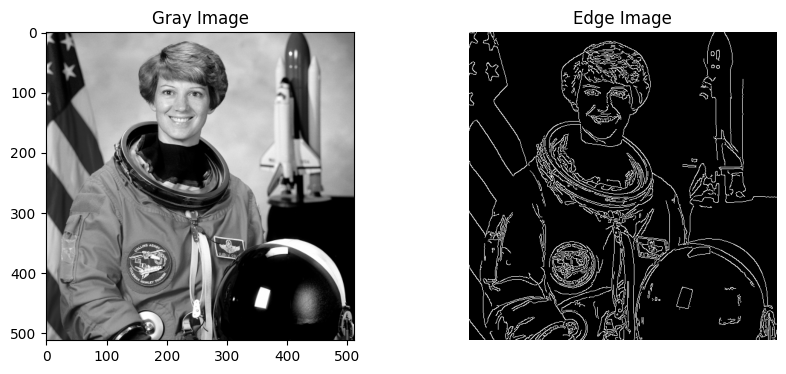

In [3]:
# 가장자리 추출 버전 이미지 확인하기
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image_gray, cmap="gray")
plt.title("Gray Image")

plt.subplot(1,2,2)
plt.imshow(edges, cmap="gray")
plt.title("Edge Image")
plt.axis("off")

plt.show()

# 두번째 예제
opencv 에서 제공하는 haar 캐스케이드 (=사전학습모델)을 활용해서 사람 얼굴 감지 등의 간단한 객체 탐지 방법 구현

In [8]:
from pathlib import Path
from urllib.request import urlretrieve

model_path = Path("/content/face_detection_yunet.onnx")

url = ("https://github.com/opencv/opencv_zoo/raw/refs/heads/main/"
       "models/face_detection_yunet/"
       "face_detection_yunet_2023mar.onnx")

if not model_path.exists():
  urlretrieve(url, str(model_path))
  print("model download complete")
else:
  print("model is already downloaded")

print(f"모델 경로: {model_path}")



model download complete
모델 경로: /content/face_detection_yunet.onnx


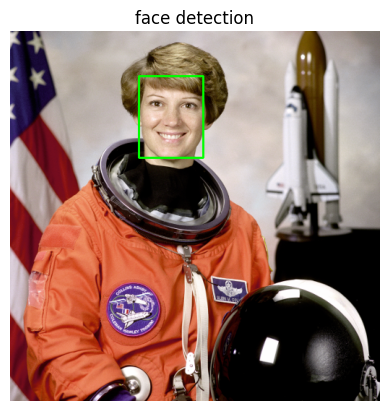

In [9]:
h,w = image.shape[:2]

face_detector = cv2.FaceDetectorYN.create(str(model_path), "", (w,h), score_threshold=0.8)

_, image_face = face_detector.detect(image)

output=image.copy()

if image_face is not None:
  for face in image_face:
    x,y,w,h = face[:4].astype(int)

  cv2.rectangle(output, (x,y), (x+w, y+h), (0,255,0),2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("face detection")
plt.axis("off")
plt.show()

# 세번째 예제
tensorflow 를 활용하여 이미지 분류  

분류 작업은 데이터셋에 매우 의존적인 작업이다.  
단순하고 해상도가 낮은 이미지 데이터셋을 분류하는 경우 랜덤 포레스트나, 얕은 신경망 구조를 합친 앙상블 기법으로 충분하다.  
복잡하고 고해상도 이미지 데이터셋을 분류하는 경우 클래스 전반의 시각적 특징과 패턴을 학습하는 합성곱 신경망을 포함해 심층 신경망 아키텍처가 최선일 경우가 많다.  

아래 예제는 10개의 클래스를 구하는 분류 데이터셋 (=Fashion-MNIST)이고, 저해상도의 의류 이미지로 구성되어 있다.  
간단하게 데이터 전처리를 거치고 -> train/test 로 분할한 후 -> 간단한 합성곱 신경망으로 정의된 모델을 학습시킨 후 -> 테스트세트를 모델에 입력하여 클래스 예측 실시

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# 픽셀값을 정규화시키기
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# 간단한 합성곱 신경망 아키텍처
model = models.Sequential([
    layers.Reshape((28,28,1), input_shape=(28,28)),
    layers.Conv2D(32,3,activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")    # softmax는 범주 별로 '확률'을 출력하는 경우에 활용
])

# 모델 학습 시킬 준비 = 어떻게 학습할지 설정
model.compile(
    optimizer="adam",       # 오차 = loss 를 줄이도록 모델의 가중치를 업데이트하는 알고리즘
    loss="sparse_categorical_crossentropy",   # 다중 클래스 분류 문제에서 사용하는 손실 함수 (정답이 정수이어야 함)
      # 손실함수는 예측과 정답의 차이를 계산하는 방법 = 알고리즘
    metrics=["accuracy"]    # 학습하면서 정답을 맞힌 비율 = 정확도
)

# 모델 학습 진행
history = model.fit(
    train_images, train_labels, epochs=5, validation_split=0.1, verbose=2
    # epoch는 train 데이터를 전체적으로 5번 반복
    # validation_split은 전달한 데이터의 10%를 검증용으로 분리하기
    # verbose는 실행과정을 화면에 얼마나 자세히 출력할지 정하는 옵션, 2는 epoch 마다 결과 한줄 씩 출력 / 0은 출력X / 1은 진행막대와 학습지표 표시
)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1688/1688 - 32s - 19ms/step - accuracy: 0.8526 - loss: 0.4218 - val_accuracy: 0.8888 - val_loss: 0.3112
Epoch 2/5
1688/1688 - 40s - 24ms/step - accuracy: 0.8968 - loss: 0.2887 - val_accuracy: 0.9042 - val_loss: 0.2747
Epoch 3/5
1688/1688 - 28s - 17ms/step - accuracy: 0.9116 - loss: 0.2450 - val_accuracy: 0.9038 - val_loss: 0.2750
Epoch 4/5
1688/1688 - 28s - 17ms/step - accuracy: 0.9201 - loss: 0.2136 - val_accuracy: 0.9080 - val_loss: 0.2516
Epoch 5/5
1688/1688 - 31s - 18ms/step - accuracy: 0.9311 - loss: 0.1874 - val_accuracy: 0.9128 - val_loss: 0.2489


In [13]:
# 테스트 세트로 평가
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"test accuracy: {test_acc:.3f}")

313/313 - 2s - 7ms/step - accuracy: 0.9068 - loss: 0.2656
test accuracy: 0.907
